Used_Car_Price_Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Used_Car_Price_Prediction-selected-columns.csv')

In [3]:
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt


In [4]:
df.shape

(7400, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   car_name      7400 non-null   str  
 1   yr_mfr        7400 non-null   int64
 2   fuel_type     7400 non-null   str  
 3   kms_run       7400 non-null   int64
 4   sale_price    7400 non-null   int64
 5   city          7400 non-null   str  
 6   times_viewed  7400 non-null   int64
 7   body_type     7297 non-null   str  
 8   transmission  6844 non-null   str  
 9   variant       7400 non-null   str  
dtypes: int64(4), str(6)
memory usage: 946.4 KB


In [6]:
df.isnull().sum()

car_name          0
yr_mfr            0
fuel_type         0
kms_run           0
sale_price        0
city              0
times_viewed      0
body_type       103
transmission    556
variant           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['body_type'].value_counts()

body_type
hatchback       4358
sedan           1483
suv             1103
luxury suv       189
luxury sedan     163
Name: count, dtype: int64

In [11]:
df['transmission'].value_counts()

transmission
manual       6214
automatic     629
Name: count, dtype: int64

In [12]:
df['body_type'] = df['body_type'].fillna(df['body_type'].mode()[0], inplace = True)

In [13]:
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0], inplace= True)

In [14]:
df.isnull().sum()

car_name        0
yr_mfr          0
fuel_type       0
kms_run         0
sale_price      0
city            0
times_viewed    0
body_type       0
transmission    0
variant         0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7399 entries, 0 to 7398
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   car_name      7399 non-null   str  
 1   yr_mfr        7399 non-null   int64
 2   fuel_type     7399 non-null   str  
 3   kms_run       7399 non-null   int64
 4   sale_price    7399 non-null   int64
 5   city          7399 non-null   str  
 6   times_viewed  7399 non-null   int64
 7   body_type     7399 non-null   str  
 8   transmission  7399 non-null   str  
 9   variant       7399 non-null   str  
dtypes: int64(4), str(6)
memory usage: 952.3 KB


categoical Clm

In [16]:
categorical_clm = ['fuel_type', 'city', 'body_type', 'transmission']

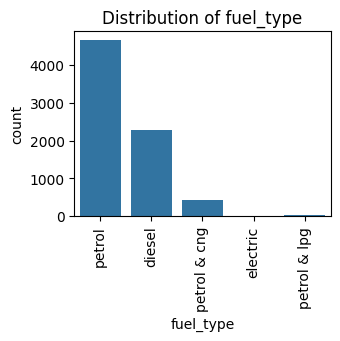

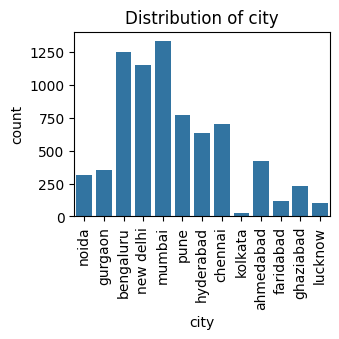

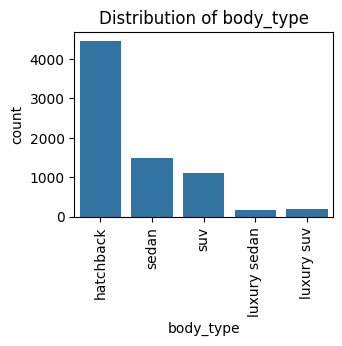

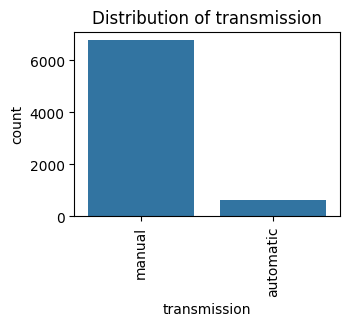

In [17]:
for clm in categorical_clm:
    plt.subplot(2,2,2)
    sns.countplot(data = df, x = clm)
    plt.title(f"Distribution of {clm}")
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()

In [18]:
df['car_name'].nunique()

185

In [19]:
df['variant'].nunique()

943

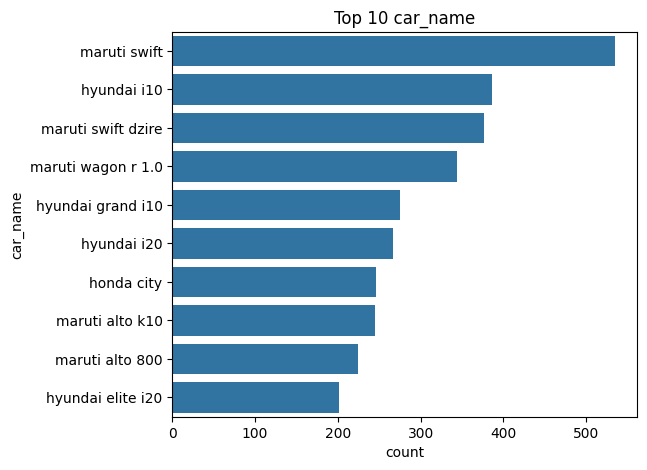

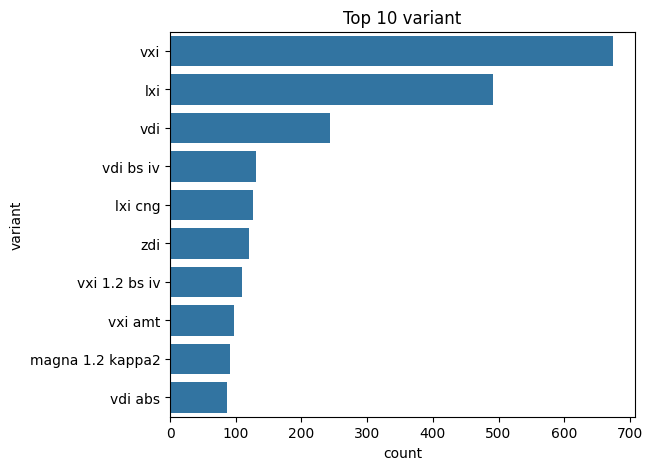

In [20]:
for clm in ['car_name', 'variant']:
    top10 = df[clm].value_counts().head(10)
    plt.figure(figsize=(6,5))
    sns.countplot(
        data=df,
        y=clm,
        order=top10.index
    )
    plt.title(f"Top 10 {clm}")
    plt.show()

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7399 entries, 0 to 7398
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   car_name      7399 non-null   str  
 1   yr_mfr        7399 non-null   int64
 2   fuel_type     7399 non-null   str  
 3   kms_run       7399 non-null   int64
 4   sale_price    7399 non-null   int64
 5   city          7399 non-null   str  
 6   times_viewed  7399 non-null   int64
 7   body_type     7399 non-null   str  
 8   transmission  7399 non-null   str  
 9   variant       7399 non-null   str  
dtypes: int64(4), str(6)
memory usage: 952.3 KB


In [22]:
numeric_clm = ['yr_mfr', 'kms_run', 'sale_price', 'times_viewed']

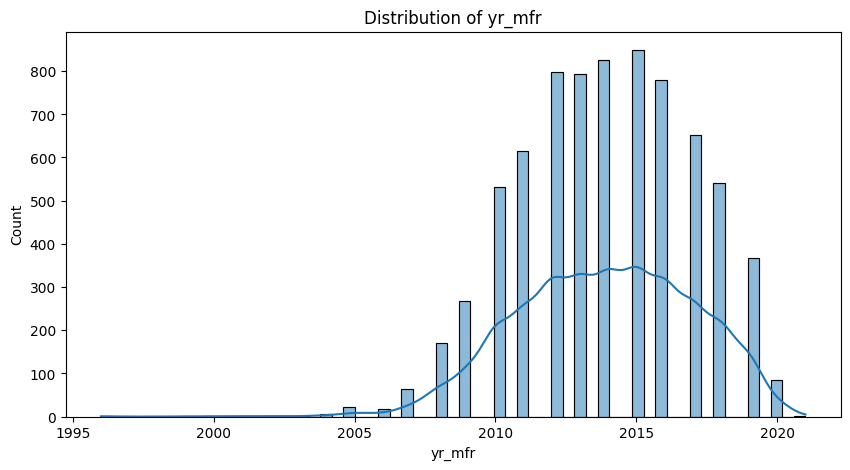

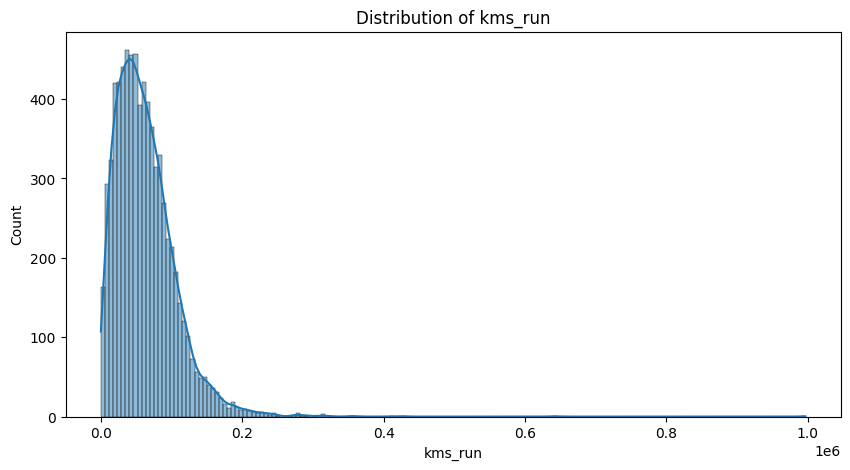

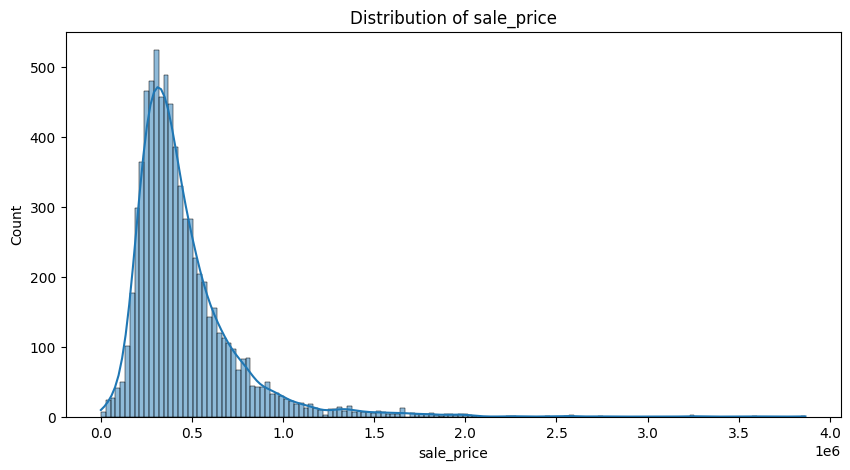

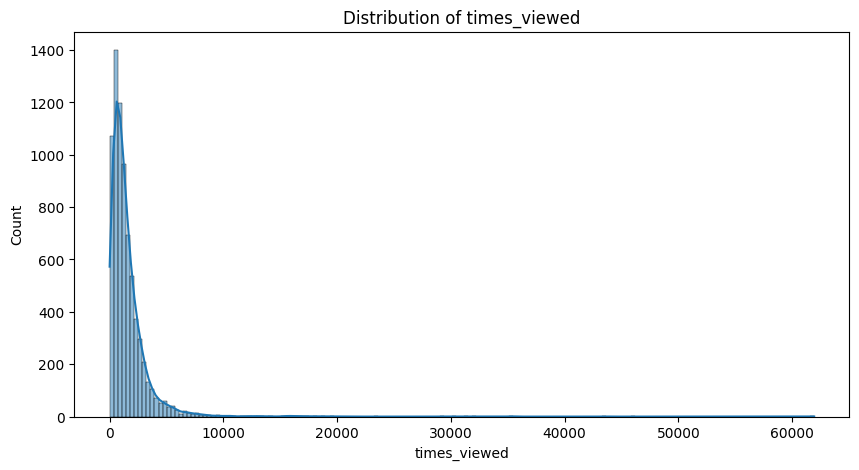

In [27]:
for clm in numeric_clm :
    plt.figure(figsize = (10, 5))
    sns.histplot(data = df, x = clm, kde= True)
    plt.title(f"Distribution of {clm}")
    plt.show()

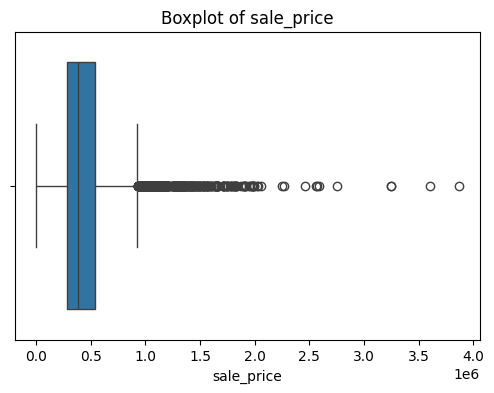

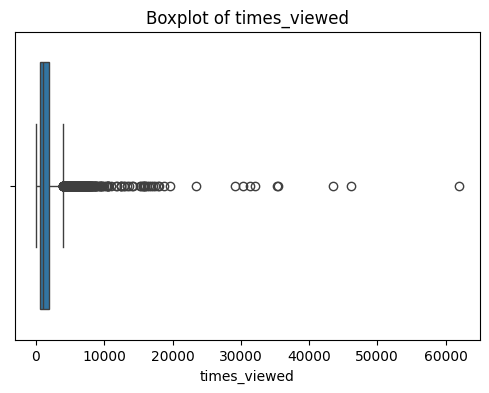

In [37]:
for clm in ['sale_price', 'times_viewed']:
    plt.figure(figsize= (6,4))
    sns.boxplot(data = df, x = clm)
    plt.title(f"Boxplot of {clm}")
    plt.show()

In [31]:
for col in ["sale_price", "times_viewed"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col)
    print("Lower:", lower)
    print("Upper:", upper)
    print("Outliers:", len(outliers))
    print()

sale_price
Lower: -107276.0
Upper: 928524.0
Outliers: 414

times_viewed
Lower: -1501.25
Upper: 3980.75
Outliers: 416



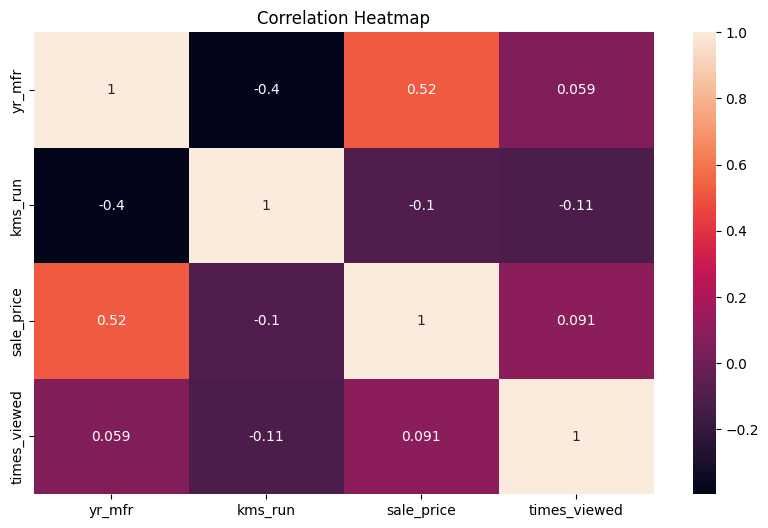

In [34]:
corr = df[numeric_clm].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

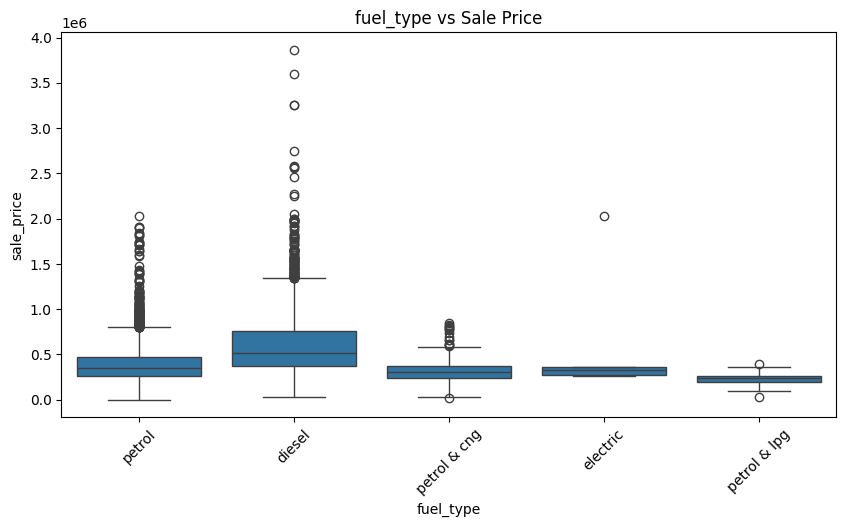

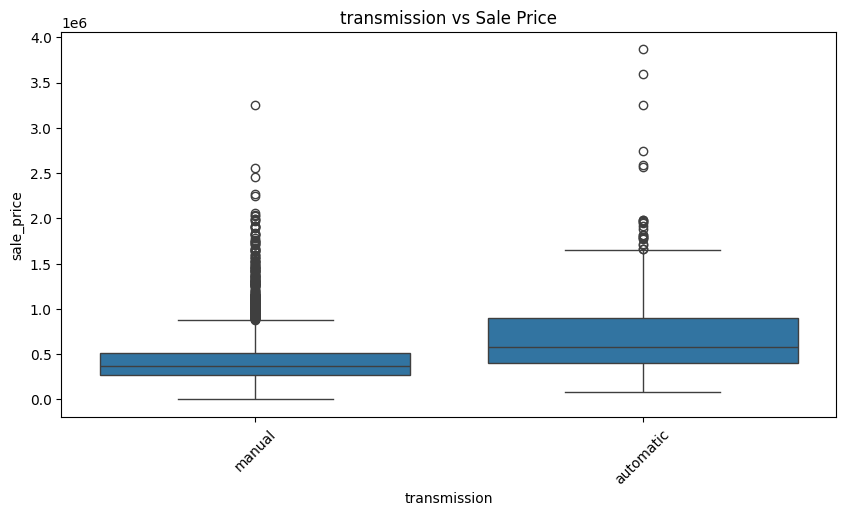

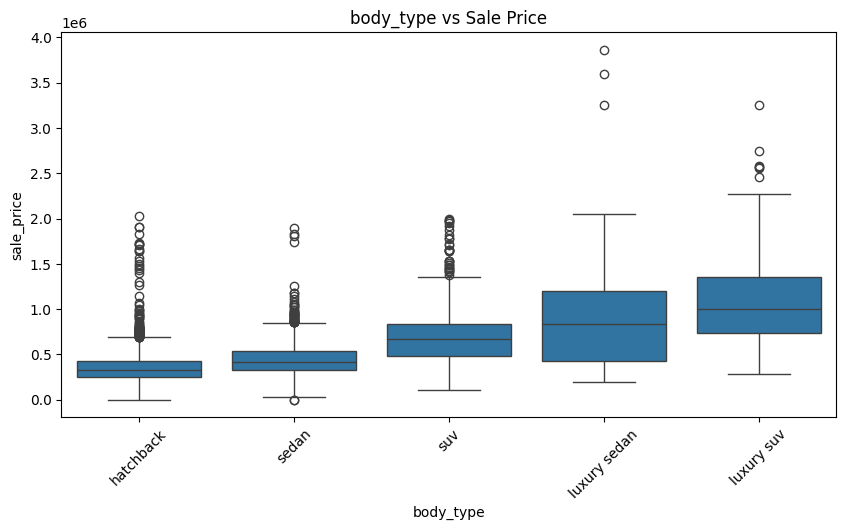

In [35]:
for col in ["fuel_type", "transmission", "body_type"]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y="sale_price")
    plt.title(f"{col} vs Sale Price")
    plt.xticks(rotation=45)
    plt.show()

In [38]:
X = df.drop('sale_price', axis = 1)
y = df['sale_price']

In [39]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size= 0.2,
    random_state=42
)

In [42]:
X_train.dtypes

car_name          str
yr_mfr          int64
fuel_type         str
kms_run         int64
city              str
times_viewed    int64
body_type         str
transmission      str
variant           str
dtype: object

In [43]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_ohe = encoder.fit_transform(X_train[categorical_clm])
test_ohe = encoder.transform(X_test[categorical_clm])

In [45]:
cat_cols = ["fuel_type", "transmission", "body_type", "city"]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)

In [46]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [47]:
X_train = X_train_encoded
X_test = X_test_encoded

In [48]:
print(X_train.shape)
print(X_test.shape)

(5919, 26)
(1480, 26)
